# ImplicitRandomizedSchwarzPrimitive — Python reimplementation via pythonnet
IMPORTANT: CHOOSE THE LEAP71 INTERPRETER: in the upper right corner of this iPython window you can select the interpreter

This notebook reproduces the `RandomTask` example originally in
`LEAP71_LatticeLibrary-main/Examples/Ex_ImplicitLibraryRandomTask.cs`
in Python, with two enhancements over the C# original:

1. **RBF deformation field** — the C# `RandomDeformationField` uses simple
   trilinear interpolation of a regular noise grid. Here the sparse control
   points are fitted with a `scipy.interpolate.RBFInterpolator` (thin-plate
   spline), then baked into a dense grid for fast per-voxel lookup.
2. **Field visualisation** — a dedicated cell plots the displacement field
   on a 2D slice with quiver arrows and a magnitude heatmap.

**Structure**

| Cell | What it does |
|------|-------------|
| 1 | Imports & path setup |
| 2 | `RBFDeformationField` Python class |
| 3 | Visualise the deformation field (2D slices, quiver, heatmap) |
| 4 | SDF + geometry construction function |
| 5 | Run the construction (toggle `HEADLESS` here) |
| 6 | Load & visualise the resulting VDB |

> **Prerequisite:** build the C# project before running —
> `cd PicoGK_Examples-main && dotnet build PicoGKExamples.csproj`
>
> The `DelegateImplicit` C# bridge (`src/DelegateImplicit.cs`) must be
> compiled into `PicoGKExamples.dll`. It wraps a Python `Func<Vector3, float>`
> as a `PicoGK.IImplicit` so Python SDFs can be passed to
> `Sh.voxIntersectImplicit`.

## Cell 1 — Imports

In [1]:
import os
import sys
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── X11 / Mesa environment (needed for the PicoGK viewer window) ──────────
os.environ.setdefault('DISPLAY', ':2')
xdg_dir = f'/tmp/xdg-runtime-{os.getuid()}'
os.makedirs(xdg_dir, mode=0o700, exist_ok=True)
os.environ['XDG_RUNTIME_DIR'] = xdg_dir
os.environ.setdefault('GDK_BACKEND', 'x11')
os.environ.setdefault('LIBGL_ALWAYS_SOFTWARE', '1')
os.environ['MESA_LOADER_DRIVER_OVERRIDE'] = 'swr,llvmpipe'
os.environ['MESA_SHADER_CACHE'] = 'false'
os.environ['MESA_SHADER_CACHE_DIR'] = ''
os.environ['ZSTD_NBTHREADS'] = '1'

# ── locate leap71_bindings.py ─────────────────────────────────────────────
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'leap71_bindings.py').exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'leap71_bindings.py').exists():
    raise FileNotFoundError('Cannot find leap71_bindings.py')
sys.path.insert(0, str(REPO_ROOT))

import leap71_bindings as leap71
from leap71_bindings import (
    Single, Vector3,
    LocalFrame, BaseBox,
    Sh, Cp,
    DelegateImplicit, Func,
    export_voxels_to_vdb, run_in_library,
)

OUTPUT_DIR = REPO_ROOT / 'Examples'
OUTPUT_DIR.mkdir(exist_ok=True)
vdb_PATH   = OUTPUT_DIR / 'ImplicitRandomSchwarzPrimitive_Python.vdb'

print('Bindings loaded.')
print(f'Output → {OUTPUT_DIR}')

Bindings loaded.
Output → /workspace/LEAP71_version_KBE/Examples


## Cell 2 — `RBFDeformationField`

**How it differs from the C# `RandomDeformationField`**

| | C# original | Python (this notebook) |
|---|---|---|
| Control-point layout | Regular grid, spacing = `fResolution` | Same regular grid |
| Interpolation | Trilinear between grid corners | **RBF thin-plate spline** fit to grid points, baked to a fine grid, then trilinear |
| Effect | Sharp cell boundaries visible in the deformed TPMS | Smoothly varying, globally coherent displacement |

The RBF is fitted once at construction time and evaluated on a dense baked grid (`bake_spacing`). At SDF evaluation time, fast trilinear lookup into the baked grid is used — this keeps the per-voxel cost low even though RBF evaluation itself is expensive.

In [ ]:
from scipy.interpolate import RBFInterpolator

class RBFDeformationField:
    """
    3D displacement field built by fitting RBF thin-plate splines to random
    control-point displacements, then baking to a dense grid for fast lookup.

    Mirrors the role of C# RandomDeformationField but with smoother
    spatial variation.
    """

    def __init__(
        self,
        bbox_min: tuple,
        bbox_max: tuple,
        control_spacing: float = 20.0,
        amplitude: float = 8.0,
        bake_spacing: float = 2.0,
        seed: int = 42,
    ):
        """
        Parameters
        ----------
        bbox_min / bbox_max : world-space extent of the field (mm)
        control_spacing     : spacing of the sparse RBF control points (mm)
                              — analogous to C# fResolution (= 20 mm)
        amplitude           : max displacement magnitude per axis (mm)
                              — analogous to C# fDeformationAmplitude (= 8 mm)
        bake_spacing        : grid spacing of the dense pre-computed field (mm)
        seed                : random seed for reproducibility
        """
        self.bbox_min = np.asarray(bbox_min, dtype=np.float64)
        self.bbox_max = np.asarray(bbox_max, dtype=np.float64)
        self.amplitude = amplitude

        rng = np.random.default_rng(seed)

        # ── 1. Sparse control points ──────────────────────────────────────
        axes = [np.arange(lo, hi + control_spacing, control_spacing)
                for lo, hi in zip(self.bbox_min, self.bbox_max)]
        XX, YY, ZZ = np.meshgrid(*axes, indexing='ij')
        ctrl_pts = np.column_stack([XX.ravel(), YY.ravel(), ZZ.ravel()])

        # Random displacement vector at each control point
        disp_ctrl = rng.uniform(-amplitude, amplitude, (len(ctrl_pts), 3))

        self.ctrl_pts  = ctrl_pts
        self.disp_ctrl = disp_ctrl

        # ── 2. Fit one RBF per displacement axis ─────────────────────────
        print(f'  Fitting RBF ({len(ctrl_pts)} control points) …')
        self._rbf = [
            RBFInterpolator(ctrl_pts, disp_ctrl[:, ax],
                            kernel='thin_plate_spline', degree=1)
            for ax in range(3)
        ]

        # ── 3. Bake to a dense grid for fast per-voxel trilinear lookup ──
        bake_axes = [np.arange(lo, hi + bake_spacing, bake_spacing)
                     for lo, hi in zip(self.bbox_min, self.bbox_max)]
        BX, BY, BZ = np.meshgrid(*bake_axes, indexing='ij')
        bake_pts = np.column_stack([BX.ravel(), BY.ravel(), BZ.ravel()])

        nx, ny, nz = BX.shape
        print(f'  Baking dense grid {nx}×{ny}×{nz} (spacing {bake_spacing} mm) …')
        baked = np.column_stack([rbf(bake_pts) for rbf in self._rbf])
        # shape: (nx, ny, nz, 3)
        self._grid      = baked.reshape(nx, ny, nz, 3)
        self._bake_axes = bake_axes
        self._nx, self._ny, self._nz = nx, ny, nz
        self._step = np.array([a[1] - a[0] if len(a) > 1 else 1.0
                                for a in bake_axes])
        print('  RBFDeformationField ready.')

    # ── Evaluation ────────────────────────────────────────────────────────

    def get_displacement(self, x: float, y: float, z: float) -> tuple:
        """Return (dx, dy, dz) via trilinear lookup in the baked grid."""
        d = self._trilinear(x, y, z)
        return float(d[0]), float(d[1]), float(d[2])

    def get_displacement_batch(self, pts: np.ndarray) -> np.ndarray:
        """Vectorised batch query; pts is (N, 3), returns (N, 3)."""
        # Clamp
        pts = np.clip(pts, self.bbox_min, self.bbox_max)
        # Fractional grid indices
        gx = (pts[:, 0] - self._bake_axes[0][0]) / self._step[0]
        gy = (pts[:, 1] - self._bake_axes[1][0]) / self._step[1]
        gz = (pts[:, 2] - self._bake_axes[2][0]) / self._step[2]
        ix = np.clip(gx.astype(int), 0, self._nx - 2)
        iy = np.clip(gy.astype(int), 0, self._ny - 2)
        iz = np.clip(gz.astype(int), 0, self._nz - 2)
        tx = gx - ix;  ty = gy - iy;  tz = gz - iz
        tx = tx[:, None];  ty = ty[:, None];  tz = tz[:, None]
        g = self._grid
        return (g[ix,   iy,   iz  ] * (1-tx)*(1-ty)*(1-tz)
              + g[ix+1, iy,   iz  ] *    tx *(1-ty)*(1-tz)
              + g[ix,   iy+1, iz  ] * (1-tx)*   ty *(1-tz)
              + g[ix+1, iy+1, iz  ] *    tx *   ty *(1-tz)
              + g[ix,   iy,   iz+1] * (1-tx)*(1-ty)*   tz
              + g[ix+1, iy,   iz+1] *    tx *(1-ty)*   tz
              + g[ix,   iy+1, iz+1] * (1-tx)*   ty *   tz
              + g[ix+1, iy+1, iz+1] *    tx *   ty *   tz)

    def _trilinear(self, x: float, y: float, z: float) -> np.ndarray:
        """Single-point trilinear lookup; returns displacement (3,)."""
        x = float(np.clip(x, self.bbox_min[0], self.bbox_max[0]))
        y = float(np.clip(y, self.bbox_min[1], self.bbox_max[1]))
        z = float(np.clip(z, self.bbox_min[2], self.bbox_max[2]))
        gx = (x - self._bake_axes[0][0]) / self._step[0]
        gy = (y - self._bake_axes[1][0]) / self._step[1]
        gz = (z - self._bake_axes[2][0]) / self._step[2]
        ix = min(int(gx), self._nx - 2)
        iy = min(int(gy), self._ny - 2)
        iz = min(int(gz), self._nz - 2)
        tx = gx - ix;  ty = gy - iy;  tz = gz - iz
        g = self._grid
        return (g[ix,   iy,   iz  ] * (1-tx)*(1-ty)*(1-tz)
              + g[ix+1, iy,   iz  ] *    tx *(1-ty)*(1-tz)
              + g[ix,   iy+1, iz  ] * (1-tx)*   ty *(1-tz)
              + g[ix+1, iy+1, iz  ] *    tx *   ty *(1-tz)
              + g[ix,   iy,   iz+1] * (1-tx)*(1-ty)*   tz
              + g[ix+1, iy,   iz+1] *    tx *(1-ty)*   tz
              + g[ix,   iy+1, iz+1] * (1-tx)*   ty *   tz
              + g[ix+1, iy+1, iz+1] *    tx *   ty *   tz)


# ── Instantiate field (bounding box = 50mm box grown by amplitude + 0.2) ──
# Mirrors the C# lines:
#   BBox3 oBoundingBox = voxBounding.oCalculateBoundingBox();
#   oBoundingBox.Grow(fDeformationAmplitude + 0.2f);
F_BOX_HALF        = 25.0   # half-size of the 50mm bounding cube
F_AMPLITUDE       = 8.0
F_UNIT_SIZE       = 5.0
F_WALL_THICKNESS  = 1.0
F_CTRL_SPACING    = 20.0   # C# fUnderlayingGridSize

grow = F_AMPLITUDE + 0.2
BBOX_MIN = (-F_BOX_HALF - grow,) * 3
BBOX_MAX = ( F_BOX_HALF + grow,) * 3

field = RBFDeformationField(
    bbox_min       = BBOX_MIN,
    bbox_max       = BBOX_MAX,
    control_spacing = F_CTRL_SPACING,
    amplitude      = F_AMPLITUDE,
    bake_spacing   = 1.5,
    seed           = 42,
)
print(f'\nControl points: {len(field.ctrl_pts)}')
print(f'Baked grid shape: {field._grid.shape[:3]}')

  Fitting RBF (125 control points) …
  Baking dense grid 46×46×46 (spacing 1.5 mm) …
  RBFDeformationField ready.

Control points: 125
Baked grid shape: (46, 46, 46)


## Cell 3 — Visualise the deformation field

Three plots:
1. **Quiver (XY-plane at z = 0)** — shows direction and relative magnitude of
   displacement projected onto the horizontal midplane.
2. **Magnitude heatmap (XY-plane at z = 0)** — total 3D displacement length.
3. **Magnitude heatmap (XZ-plane at y = 0)** — second cross-section to show
   the field varies in all three dimensions.

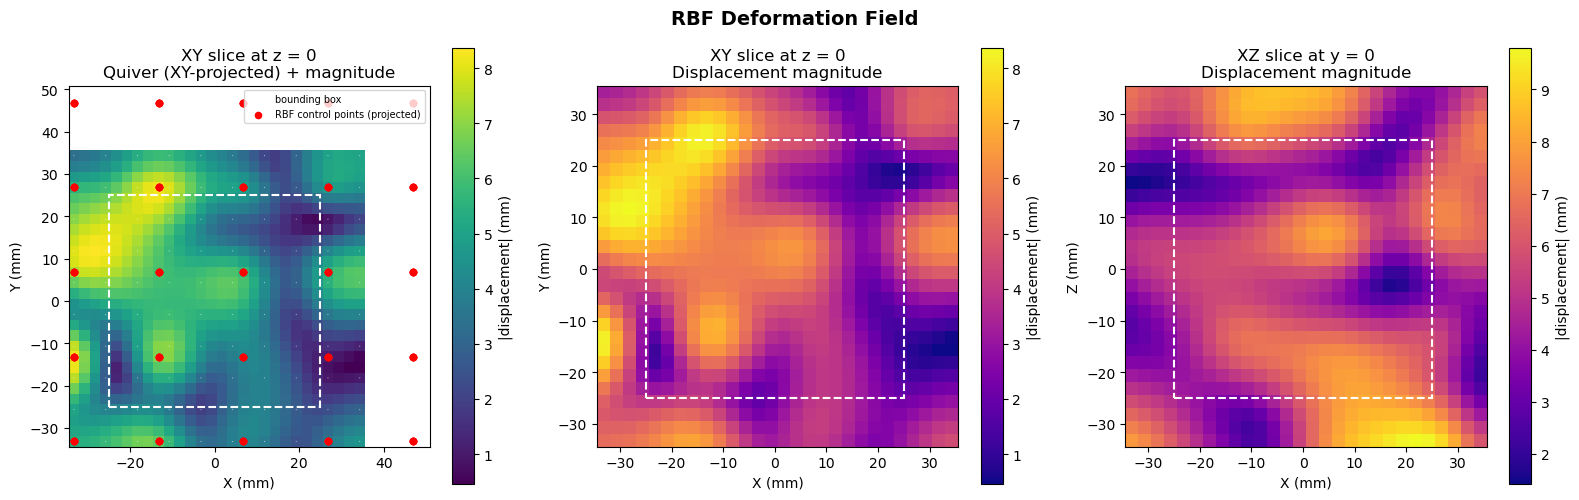

Field stats — min: 0.46 mm  max: 8.36 mm  mean: 4.43 mm


In [3]:
# ── Sample the field on two 2D slices ─────────────────────────────────────
SAMPLE_STEP = 2.5   # mm — sample spacing for visualisation

xs = np.arange(BBOX_MIN[0], BBOX_MAX[0] + SAMPLE_STEP, SAMPLE_STEP)
ys = np.arange(BBOX_MIN[1], BBOX_MAX[1] + SAMPLE_STEP, SAMPLE_STEP)
zs = np.arange(BBOX_MIN[2], BBOX_MAX[2] + SAMPLE_STEP, SAMPLE_STEP)

def sample_slice_xy(z_val: float):
    """Return displacement (nx, ny, 3) on the XY plane at z = z_val."""
    XX, YY = np.meshgrid(xs, ys, indexing='ij')
    ZZ = np.full_like(XX, z_val)
    pts = np.column_stack([XX.ravel(), YY.ravel(), ZZ.ravel()])
    return field.get_displacement_batch(pts).reshape(len(xs), len(ys), 3)

def sample_slice_xz(y_val: float):
    """Return displacement (nx, nz, 3) on the XZ plane at y = y_val."""
    XX, ZZ = np.meshgrid(xs, zs, indexing='ij')
    YY = np.full_like(XX, y_val)
    pts = np.column_stack([XX.ravel(), YY.ravel(), ZZ.ravel()])
    return field.get_displacement_batch(pts).reshape(len(xs), len(zs), 3)

disp_xy = sample_slice_xy(0.0)
disp_xz = sample_slice_xz(0.0)

mag_xy = np.linalg.norm(disp_xy, axis=-1)   # (nx, ny)
mag_xz = np.linalg.norm(disp_xz, axis=-1)   # (nx, nz)

# ── Quiver subsample (every n-th point for readability) ───────────────────
Q = 3  # plot every Q-th grid point in each direction
XX_q, YY_q = np.meshgrid(xs[::Q], ys[::Q], indexing='ij')
DX_q = disp_xy[::Q, ::Q, 0]
DY_q = disp_xy[::Q, ::Q, 1]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RBF Deformation Field', fontsize=14, fontweight='bold')

box_rect = plt.Rectangle(
    (-F_BOX_HALF, -F_BOX_HALF), 2*F_BOX_HALF, 2*F_BOX_HALF,
    linewidth=1.5, edgecolor='white', facecolor='none', linestyle='--', label='bounding box'
)

# -- Plot 1: quiver (XY at z=0) -------------------------------------------
ax = axes[0]
im = ax.pcolormesh(xs, ys, mag_xy.T, cmap='viridis', shading='auto')
fig.colorbar(im, ax=ax, label='|displacement| (mm)')
scale = F_AMPLITUDE * Q * SAMPLE_STEP * 0.5
ax.quiver(XX_q, YY_q, DX_q, DY_q,
          color='white', alpha=0.75, scale=scale, scale_units='xy',
          width=0.003)
ax.add_patch(box_rect)
ax.scatter(field.ctrl_pts[:, 0], field.ctrl_pts[:, 1],
           c='red', s=20, zorder=5, label='RBF control points (projected)')
ax.set_aspect('equal')
ax.set_xlabel('X (mm)');  ax.set_ylabel('Y (mm)')
ax.set_title('XY slice at z = 0\nQuiver (XY-projected) + magnitude')
ax.legend(fontsize=7)

# -- Plot 2: magnitude heatmap XY -----------------------------------------
ax2 = axes[1]
im2 = ax2.pcolormesh(xs, ys, mag_xy.T, cmap='plasma', shading='auto')
fig.colorbar(im2, ax=ax2, label='|displacement| (mm)')
box_rect2 = plt.Rectangle(
    (-F_BOX_HALF, -F_BOX_HALF), 2*F_BOX_HALF, 2*F_BOX_HALF,
    linewidth=1.5, edgecolor='white', facecolor='none', linestyle='--'
)
ax2.add_patch(box_rect2)
ax2.set_aspect('equal')
ax2.set_xlabel('X (mm)');  ax2.set_ylabel('Y (mm)')
ax2.set_title('XY slice at z = 0\nDisplacement magnitude')

# -- Plot 3: magnitude heatmap XZ -----------------------------------------
ax3 = axes[2]
im3 = ax3.pcolormesh(xs, zs, mag_xz.T, cmap='plasma', shading='auto')
fig.colorbar(im3, ax=ax3, label='|displacement| (mm)')
box_rect3 = plt.Rectangle(
    (-F_BOX_HALF, -F_BOX_HALF), 2*F_BOX_HALF, 2*F_BOX_HALF,
    linewidth=1.5, edgecolor='white', facecolor='none', linestyle='--'
)
ax3.add_patch(box_rect3)
ax3.set_aspect('equal')
ax3.set_xlabel('X (mm)');  ax3.set_ylabel('Z (mm)')
ax3.set_title('XZ slice at y = 0\nDisplacement magnitude')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'RBFDeformationField_slices.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Field stats — min: {mag_xy.min():.2f} mm  max: {mag_xy.max():.2f} mm  mean: {mag_xy.mean():.2f} mm')

## Cell 4 — SDF + geometry construction

Translation of `RandomTask()` from `Ex_ImplicitLibraryRandomTask.cs`:

| Step | C# | Python |
|------|----|--------|
| 1 | `BaseBox(new LocalFrame(), 50, 50, 50)` → `oConstructVoxels()` | same |
| 2 | `RandomDeformationField(bbox, 20, -8, 8)` | `RBFDeformationField` (built in Cell 2) |
| 2b | `ImplicitRandomizedSchwarzPrimitive(10, 0.5, field)` | `schwarz_rbf_sdf` Python closure |
| 3 | `voxBounding.voxIntersectImplicit(pattern)` | `Sh.voxIntersectImplicit` + `DelegateImplicit` bridge |

### How `DelegateImplicit` works

Normally Python classes cannot implement the C# `IImplicit` interface directly
through pythonnet. `DelegateImplicit` (in `src/DelegateImplicit.cs`) is a thin
C# class that wraps a `Func<Vector3, float>` delegate as `IImplicit`, so a
Python function can be passed to `Sh.voxIntersectImplicit`.

In [ ]:
def build_random_schwarz(output_dir: Path, rbf_field: RBFDeformationField,
                         f_unit_size: float = 10.0,
                         f_wall_thickness: float = 0.5,
                         headless: bool = True):
    """
    Translate of RandomTask() from Ex_ImplicitLibraryRandomTask.cs.

    Must be called inside a Library.Go task thread (via run_in_library).
    """

    def preview(vox, colour=Cp.strRock, alpha=1.0):
        if not headless:
            Sh.PreviewVoxels(vox, colour, Single(alpha))

    # ── Step 1: bounding object ───────────────────────────────────────────
    print('  constructing bounding box …')
    o_box        = BaseBox(LocalFrame(), 20, 50, 50)
    vox_bounding = o_box.oConstructVoxels()

    # ── Step 2: Python SDF closure ────────────────────────────────────────
    # Mirrors ImplicitRandomizedSchwarzPrimitive.fSignedDistance:
    #   vecNoise = field.vecGetData(vecPt)
    #   vecNewPt = vecPt + vecNoise
    #   dist = |cos(k*x) + cos(k*y) + cos(k*z)| - 0.5*wallThickness
    k = (2.0 * math.pi) / f_unit_size

    def schwarz_rbf_sdf(vec) -> Single:
        x  = float(vec.X)
        y  = float(vec.Y)
        z  = float(vec.Z)
        dx, dy, dz = rbf_field.get_displacement(x, y, z)
        nx_ = x + dx
        ny_ = y + dy
        nz_ = z + dz
        dist = (math.cos(k * nx_) +
                math.cos(k * ny_) +
                math.cos(k * nz_))
        return Single(float(abs(dist) - 0.5 * f_wall_thickness))

    print('  creating DelegateImplicit …')
    impl = DelegateImplicit(Func[Vector3, Single](schwarz_rbf_sdf))

    # ── Step 3: intersect bounding voxels with the implicit SDF ──────────
    print('  intersecting with implicit Schwarz + RBF deformation …')
    print('  (each voxel calls back into Python — may take ~30–90 s) …')
    vox_implicit = Sh.voxIntersectImplicit(vox_bounding, impl)

    # ── Step 4: visualisation (no-op in headless mode) ────────────────────
    str_color = Cp.strRandom()
    preview(vox_implicit, str_color)

    # ── Export ────────────────────────────────────────────────────────────
    vdb_path = str(output_dir / 'ImplicitRandomSchwarzPrimitive_Python.vdb')
    print(f'  exporting → {vdb_path}')
    export_voxels_to_vdb(vox_implicit, vdb_path)

    print('Finished Task successfully.')
    return vox_implicit


print('build_random_schwarz() defined.')

build_random_schwarz() defined.


## Cell 5 — Run the construction

Toggle **`HEADLESS`** to control the viewer:

| `HEADLESS` | Behaviour |
|---|---|
| `True` (default) | No window. Fast, notebook-friendly. |
| `False` | PicoGK viewer opens; `Library.Go` blocks until the window is closed. |

> **Performance note** — Each voxel evaluation calls back from C# into Python
> via the `DelegateImplicit` bridge, then does a trilinear lookup in the baked
> numpy grid. At 0.5 mm voxel size the 50 mm box has ~100³ = 1M active voxels;
> expect **30–90 s** depending on your machine.

In [5]:
import time

HEADLESS   = False
VOXEL_SIZE = 0.5   # mm

t0 = time.time()
mode_label = 'headless' if HEADLESS else 'with viewer'
print(f'Starting construction  (voxel size = {VOXEL_SIZE} mm, mode = {mode_label}) …')

def _task():
    build_random_schwarz(
        OUTPUT_DIR, field,
        f_unit_size=F_UNIT_SIZE,
        f_wall_thickness=F_WALL_THICKNESS,
        headless=HEADLESS,
    )

run_in_library(_task, voxel_size=VOXEL_SIZE, output_dir=OUTPUT_DIR, headless=HEADLESS)

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f} s')
print(f'vdb written to: {vdb_PATH}')

Starting construction  (voxel size = 0.5 mm, mode = with viewer) …
      0s    0.0+ Opened /workspace/LEAP71_version_KBE/Examples/PicoGK.log
      0s    0.0+ 
      0s    0.0+ ----------------------------------------
      0s    0.0+ 
      0s    0.0+ Current time (UTC): 2026-04-30 22:30:05 (UTC)
      0s    0.0+ Current local time: 2026-04-30 22:30:05 (+00:00)
      0s    0.0+ 
      0s    0.0+ ----------------------------------------
      0s    0.0+ 
      0s    0.0+ System Info:
      0s    0.0+ 
      0s    0.0+ Machine Name:         78094785f08f
      0s    0.0+ Operating System      Ubuntu 24.04.4 LTS
      0s    0.0+ Version:              Unix 6.6.87.2
      0s    0.0+ OS Architecture:      X64
      0s    0.0+ Proc Architecture:    X64
      0s    0.0+ 64 Bit OS:            Yes
      0s    0.0+ 64 Bit Process:       Yes
      0s    0.0+ Processor Count:      20
      0s    0.0+ Working Set:          253MB
      0s    0.0+ C# Framework:         .NET 9.0.15
      0s    0.0+ C# C

Failed to create /mesa_shader_cache for shader cache (Permission denied)---disabling.


      0s    0.4+ PicoGK:    PicoGK Core Library
      0s    0.0+            1.7.1
      0s    0.0+            2024-08-03 18:24:24 picogk
      0s    0.0+ 
      0s    0.0+ VoxelSize: 0.5 (mm)
      0s    0.0+ Happy Computational Engineering!
      0s    0.0+ 
      0s    0.0+ 
      0s    0.0+ Loading lights embedded environment
      0s    0.0+ Starting tasks.
      0s    0.0+ 
  constructing bounding box …
      0s    0.0+ Loading Lights
  creating DelegateImplicit …
  intersecting with implicit Schwarz + RBF deformation …
  (each voxel calls back into Python — may take ~30–90 s) …
  exporting → /workspace/LEAP71_version_KBE/Examples/ImplicitRandomSchwarzPrimitive_Python.vdb
Finished Task successfully.
     64s   63.9+ Viewer Window Closed
     64s    0.0+ 
     64s    0.0+ ----------------------------------------
     64s    0.0+ 
     64s    0.0+ Closing log file.
     64s    0.0+ Current time (UTC): 2026-04-30 22:31:09 (UTC)
     64s    0.0+ Current local time: 2026-04-30 22:31:09

## Cell 6 — Visualise the VDB with PyVista

Reading /workspace/LEAP71_version_KBE/Examples/ImplicitRandomSchwarzPrimitive_Python.vdb …
  shape (Z,Y,X) : (105, 105, 105)
  voxel size    : 1.0 mm
  bounding box  : X [-52, 53]  Y [-52, 53]  Z [-2, 103] mm
Extracting isosurface …
  raw  : 402,348 vertices, 810,292 triangles
  decimated: 247,209 vertices, 500,000 triangles


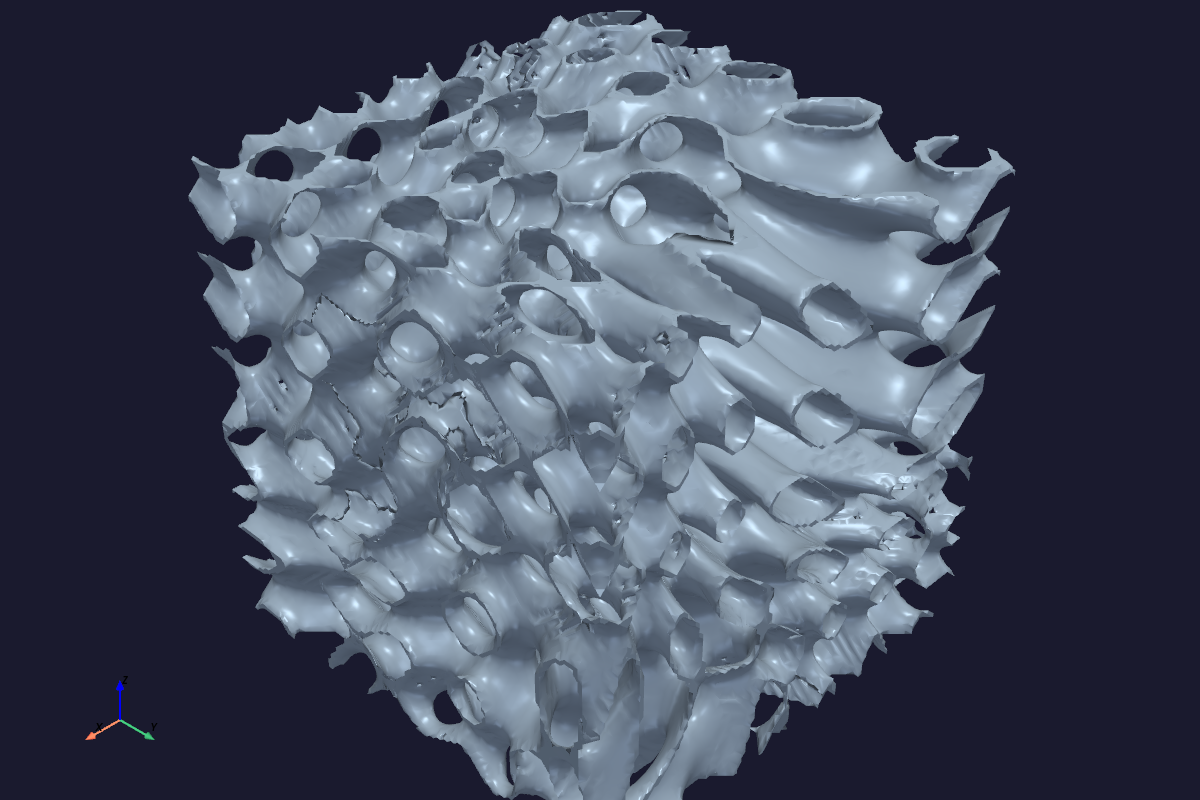

In [7]:
try:
    import pyvista as pv
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "pyvista not found — install with:  pip install 'pyvista[jupyter]'"
    ) from exc

import os, sys
import numpy as np

os.environ['MESA_SHADER_CACHE_DISABLE'] = '1'

VDB_READER_DIR = REPO_ROOT / 'vdb_reader'
if str(VDB_READER_DIR) not in sys.path:
    sys.path.insert(0, str(VDB_READER_DIR))

try:
    import vdb_numpy
except ImportError as exc:
    raise ImportError(
        f"vdb_numpy extension not found in {VDB_READER_DIR}. "
        "Build it first:\n"
        f"  cd {VDB_READER_DIR} && python setup.py build_ext --inplace"
    ) from exc

PYVISTA_BACKEND = 'static'
pv.set_jupyter_backend(PYVISTA_BACKEND)
pv.global_theme.allow_empty_mesh = True

if not vdb_PATH.exists():
    raise FileNotFoundError(
        f'VDB not found: {vdb_PATH}\nRun Cell 5 first to generate it.'
    )

print(f'Reading {vdb_PATH} …')
arr, origin, voxel_size = vdb_numpy.read_vdb_as_numpy(str(vdb_PATH))
nz, ny, nx = arr.shape
ox, oy, oz = origin
print(f'  shape (Z,Y,X) : {arr.shape}')
print(f'  voxel size    : {voxel_size} mm')
print(f'  bounding box  : '
      f'X [{ox:.0f}, {ox+nx*voxel_size:.0f}]  '
      f'Y [{oy:.0f}, {oy+ny*voxel_size:.0f}]  '
      f'Z [{oz:.0f}, {oz+nz*voxel_size:.0f}] mm')

grid = pv.ImageData(
    dimensions=(nx, ny, nz),
    spacing=(voxel_size, voxel_size, voxel_size),
    origin=(ox, oy, oz),
)
grid.point_data['sdf'] = arr.flatten()

print('Extracting isosurface …')
surface = grid.contour([0.0], scalars='sdf')
print(f'  raw  : {surface.n_points:,} vertices, {surface.n_cells:,} triangles')

target_ratio = min(1.0, 500_000 / max(surface.n_cells, 1))
if target_ratio < 1.0:
    surface = surface.decimate(1.0 - target_ratio)
    print(f'  decimated: {surface.n_points:,} vertices, {surface.n_cells:,} triangles')

pl = pv.Plotter(notebook=True, off_screen=True, window_size=(1200, 800))
pl.set_background('#1a1a2e')
pl.add_mesh(
    surface,
    color='#8ca0b8',
    smooth_shading=True,
    specular=0.6,
    specular_power=30,
    ambient=0.2,
)
pl.add_axes(label_size=(0.04, 0.04))
pl.camera_position = 'iso'
pl.camera.zoom(1.2)
pl.show()